# Task 2 · Step 2 — Clipping study (ε ∈ {0.05, 0.20, 0.50})

**Objective.** With token ratio $\rho_t(\theta)=\pi_\theta(a_t|s_t)/\pi_{\text{old}}(a_t|s_t)$ and advantage $A_t$, PPO maximises the clipped surrogate
$$L^{\text{clip}}(\theta)=\mathbb{E}_t\big[\min\big(\rho_tA_t,\ \text{clip}(\rho_t,1-\epsilon,1+\epsilon)A_t\big)\big].$$
Rewards are the terminal reward-model score plus sampled-token KL shaping, $r_t=r_{\text{task}}\mathbb{1}[t=T]-\beta_{\text{KL}}(\log\pi_\theta-\log\pi_{\text{ref}})$, and advantages use GAE, $\delta_t=r_t+\gamma V(s_{t+1})-V(s_t)$, $A_t=\sum_k(\gamma\lambda)^k\delta_{t+k}$ (γ = 1, λ = 0.95), normalised over the response tokens of the update.

**Setting.** Continuation from the supplied PPO midpoint (policy LoRA + matched value model; reference = base policy, adapter disabled), fixed course reward model, 1 prompt per update (training-pool indices 0, 1, 2, … for every run), 2 PPO epochs per rollout, policy lr 3e-6, critic LoRA lr 1e-4 / head lr 3e-4, value coefficient 0.5, missing-EOS penalty 1.0, generation cap 512 tokens during training and 768 for frozen evaluation (64 fixed held-out prompts, T = 0.7, top-p 0.9, same seed for every condition).

**Implementation notes.** LoRA dropout is disabled during the RL updates so that $\rho_t$ measures policy change rather than dropout noise. The supplied critic loads in fp16 on a T4; its trainable tensors are kept in fp32 (forward pass under fp16 autocast), because AdamW on fp16 weights produces inf/NaN on the first step. Updates with a non-finite loss or gradient are skipped and counted (none occurred).

**Definitions.** *Clip fraction*: share of valid response tokens whose ratio lies outside $[1-\epsilon,1+\epsilon]$ before clipping. *Affected-token fraction*: share of tokens where clipping actually binds (the min() selects the clipped term, so the token contributes no gradient): $\rho>1+\epsilon$ with $A>0$, or $\rho<1-\epsilon$ with $A<0$.

**Protocol.** (a) *Cached batch*: the 32 supplied rollouts (old/reference log-probs, critic values, terminal rewards) are rebuilt token by token; advantages use the released KL shaping + GAE; the current midpoint is scored on those tokens (static geometry), and an *update probe* runs the released per-rollout PPO steps on the fixed batch from the same midpoint weights for each ε. (b) *Matched forks*: 8-update continuations from the identical midpoint (same prompts, seed, β_KL = 0.10), evaluated with the common held-out protocol.

**Research question.** How does ε change the fraction of policy updates constrained by clipping and the stability of the short continuation?


In [1]:
%matplotlib inline
import os, sys, json, re
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "configs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from IPython.display import display, Markdown, HTML, Image
from common.nb_helpers import (style, load, jl, exists, pending, run, side_by_side, ci_text,
                               bootstrap_mean_diff, smooth, full_windows, PALETTE, SEQ, RES, FIG)
from common.metrics import length_stats, wilson_interval
from common.data import load_yaml
style()
print("repo root:", ROOT)

repo root: C:\Users\moize\OneDrive - Higher Education Commission\Desktop\Academics\ATML\PA2


## Run this step (optional)
The results below come from the Kaggle run of the script pipeline (`kaggle_runner.ipynb`). Set `FORCE_RUN = True`
to re-run the step's scripts from here (needs a CUDA GPU and the downloaded course assets). Existing fork adapters are reused.


In [2]:
FORCE_RUN = False
if FORCE_RUN:
    run('python -m task2_ppo.analyze_clipping --config configs/ppo.yaml')
else:
    print('Using saved results under results/ (FORCE_RUN = False).')

Using saved results under results/ (FORCE_RUN = False).


## 1. Cached-batch geometry and update probe

In [3]:
EPS = [0.05, 0.20, 0.50]
if not pending("task2_ppo/ppo_clipping_study_results.json"):
    C = load("task2_ppo/ppo_clipping_study_results.json")
    print(f"cached rollouts {C['cache']['rollouts']}, rebuilt {C['cache']['rebuilt']}, skipped {len(C['cache']['skipped'])}; "
          f"midpoint vs cached old policy: mean |log ρ| = {C['cached_static']['mean_abs_log_ratio']:.4f}")
    rows = []
    for e in EPS:
        st, pr = C["cached_static"][str(e)], C["cached_probe"].get(str(e), {}).get("geometry", {}).get(str(e), {})
        rows.append({"ε": e, "static clip fraction": st["clip_fraction"], "static affected fraction": st["affected_token_fraction"],
                     "clipped surrogate": st["clipped_surrogate"], "unclipped surrogate": st["unclipped_surrogate"],
                     "post-probe clip fraction": pr.get("clip_fraction"), "post-probe affected fraction": pr.get("affected_token_fraction"),
                     "post-probe KL(old‖new)": C["cached_probe"].get(str(e), {}).get("geometry", {}).get("approx_kl_old_new")})
    display(pd.DataFrame(rows).set_index("ε"))
    display(Image(filename=str(FIG / "task2_ppo_clipping_study.png"), width=1100))

> **Pending:** `results/task2_ppo/ppo_clipping_study_results.json` not produced yet. Run the step (Kaggle runner or the command in the run cell) and re-execute this notebook.

## 2. Matched short forks: per-update optimisation diagnostics
For each update: clip fraction at epoch 2, ratio range at epoch 2, step size KL(π_old‖π_new), rollout reward and policy gradient norm.


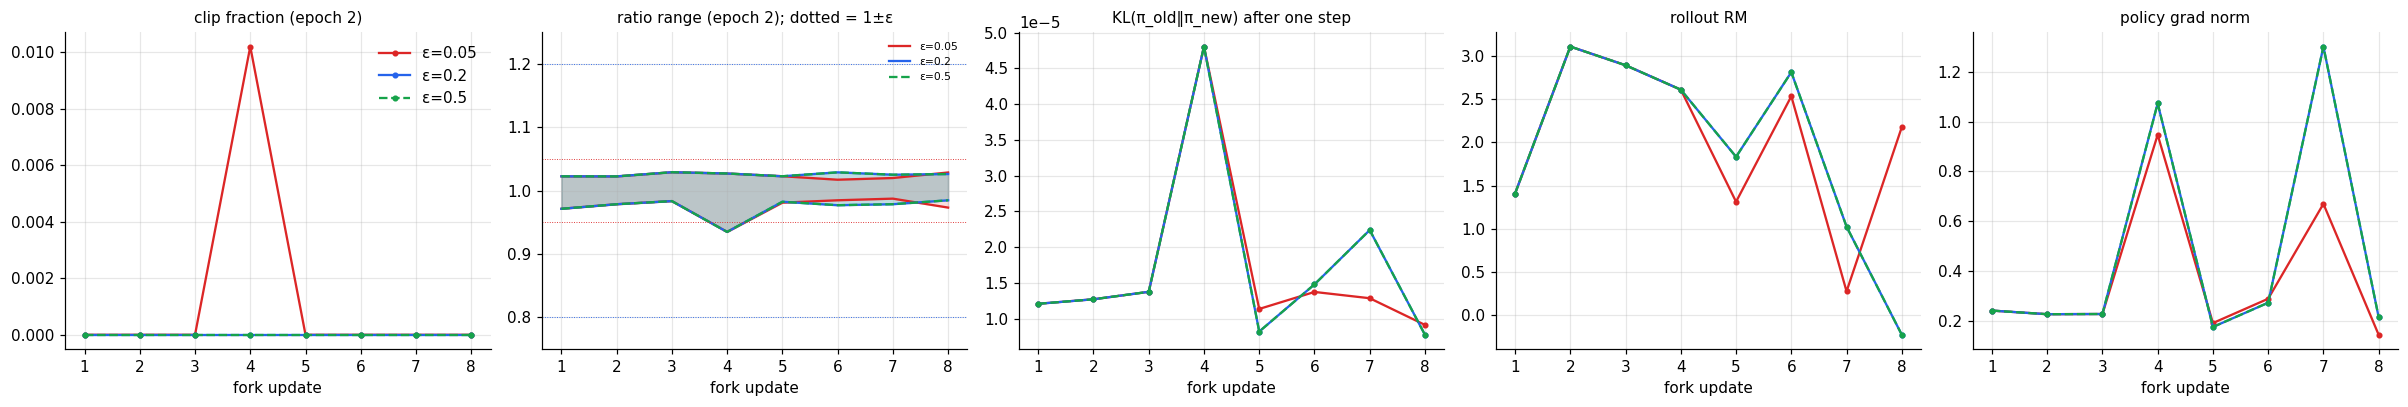

,mean clip fraction (ep 2),updates with any ratio outside 1±ε,max KL(old‖new),max ratio,grad-norm CV,final rollout KL,skipped steps
ε,,,,,,,
0.05,0.0013,1,4.8037e-05,1.0291,0.7282,4.4524e-05,"{'policy': 0, 'value': 0}"
0.20,0.0000,0,4.8037e-05,1.0291,0.9027,-1.9917e-04,"{'policy': 0, 'value': 0}"
0.50,0.0000,0,4.8037e-05,1.0291,0.9027,-1.9917e-04,"{'policy': 0, 'value': 0}"


In [4]:
fork = lambda e, k=0.10: f"fork_eps{e:.2f}_kl{k:.2f}".replace(".", "_")
FL = {e: pd.DataFrame(jl(f"task2_ppo/ppo_train_{fork(e)}.jsonl")) for e in EPS if exists(f"task2_ppo/ppo_train_{fork(e)}.jsonl")}
fig, ax = plt.subplots(1, 5, figsize=(22, 3.8))
for (e, Lf), c in zip(FL.items(), ["#DC2626", "#2563EB", "#16A34A"]):
    ls = "--" if e == 0.5 else "-"
    ax[0].plot(Lf["update"], Lf.clip_fraction_last_epoch, ls, marker="o", ms=3, color=c, label=f"ε={e}")
    ax[1].fill_between(Lf["update"], Lf.ratio_min_last_epoch, Lf.ratio_max_last_epoch, color=c, alpha=0.15)
    ax[1].plot(Lf["update"], Lf.ratio_max_last_epoch, ls, color=c, label=f"ε={e}"); ax[1].plot(Lf["update"], Lf.ratio_min_last_epoch, ls, color=c)
    ax[2].plot(Lf["update"], Lf.approx_kl_old_new_last_epoch, ls, marker="o", ms=3, color=c)
    ax[3].plot(Lf["update"], Lf.reward_rm, ls, marker="o", ms=3, color=c)
    ax[4].plot(Lf["update"], Lf.policy_grad_norm, ls, marker="o", ms=3, color=c)
for e, c in zip(EPS, ["#DC2626", "#2563EB", "#16A34A"]):
    ax[1].axhline(1 + e, color=c, lw=0.6, ls=":"); ax[1].axhline(1 - e, color=c, lw=0.6, ls=":")
ax[1].set_ylim(0.75, 1.25)
for a, t in zip(ax, ["clip fraction (epoch 2)", "ratio range (epoch 2); dotted = 1±ε", "KL(π_old‖π_new) after one step", "rollout RM", "policy grad norm"]):
    a.set_title(t, fontsize=10); a.set_xlabel("fork update")
ax[0].legend(); ax[1].legend(fontsize=7); fig.tight_layout(); plt.show()
rows = []
for e in FL:
    s = load(f"task2_ppo/ppo_summary_{fork(e)}.json"); Lf = FL[e]
    rows.append({"ε": e, "mean clip fraction (ep 2)": s["stability_mean_clip_fraction_last_epoch"],
                 "updates with any ratio outside 1±ε": int(((Lf.ratio_max_last_epoch > 1 + e) | (Lf.ratio_min_last_epoch < 1 - e)).sum()),
                 "max KL(old‖new)": s["stability_max_approx_kl_old_new"], "max ratio": s["stability_max_ratio"],
                 "grad-norm CV": s["stability_policy_grad_norm_cv"], "final rollout KL": s["final_kl"], "skipped steps": str(s["skipped_nonfinite_steps"])})
pd.DataFrame(rows).set_index("ε")

In [5]:
if 0.2 in FL and 0.5 in FL:
    num = [c for c in FL[0.2].columns if FL[0.2][c].dtype.kind == "f"]
    diff = (FL[0.2][num] - FL[0.5][num]).abs().max().max()
    print(f"max |difference| between the ε=0.20 and ε=0.50 fork logs over all numeric columns: {diff:.3g}")
    print("ratio range over all ε=0.20 fork updates: "
          f"[{FL[0.2].ratio_min_last_epoch.min():.3f}, {FL[0.2].ratio_max_last_epoch.max():.3f}]")

max |difference| between the ε=0.20 and ε=0.50 fork logs over all numeric columns: 3.16
ratio range over all ε=0.20 fork updates: [0.935, 1.029]


## 3. Held-out evaluation of the forks (64 prompts, cap 768)

In [6]:
EV = {"midpoint (start)": load("task2_ppo/ppo_eval_midpoint.json")}
EV.update({f"ε={e}": load(f"task2_ppo/ppo_eval_{fork(e)}.json") for e in EPS if exists(f"task2_ppo/ppo_eval_{fork(e)}.json")})
pd.DataFrame({k: {"RM": e["mean_reward"], "RM s.e.m.": e["sem_reward"], "KL token": e["kl_token_mean"], "entropy": e["entropy_exact"],
                  "length mean": e["length_tokens"]["mean"], "length std": e["length_tokens"]["std"], "EOS rate": e["eos_rate"]}
              for k, e in EV.items()}).T.round(4)

,RM,RM s.e.m.,KL token,entropy,length mean,length std,EOS rate
midpoint (start),1.7272,0.1691,0.0,0.9423,290.3594,260.8457,0.9375
ε=0.05,1.7785,0.1628,0.0,0.9969,295.0156,262.2768,0.9062
ε=0.2,1.8598,0.1553,-0.0,0.9795,305.3281,270.5314,0.8906
ε=0.5,1.8598,0.1553,-0.0,0.9795,305.3281,270.5314,0.8906


## 4. Facts for RQ1

In [7]:
for e in FL:
    Lf = FL[e]
    print(f"ε={e}: clip fraction (ep 2) per update {list(Lf.clip_fraction_last_epoch.round(4))}; max KL(old‖new) {Lf.approx_kl_old_new_last_epoch.max():.2e}")
if exists("task2_ppo/ppo_clipping_study_results.json"):
    C = load("task2_ppo/ppo_clipping_study_results.json")
    print("cached static affected fraction:", {e: round(C["cached_static"][str(e)]["affected_token_fraction"], 4) for e in EPS})

ε=0.05: clip fraction (ep 2) per update [0.0, 0.0, 0.0, 0.0102, 0.0, 0.0, 0.0, 0.0]; max KL(old‖new) 4.80e-05
ε=0.2: clip fraction (ep 2) per update [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]; max KL(old‖new) 4.80e-05
ε=0.5: clip fraction (ep 2) per update [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]; max KL(old‖new) 4.80e-05
